/var/folders/71/l1gpfd6j731c1qxy1_l8ffvh0000gn/T/ipykernel_92184/1282009445.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


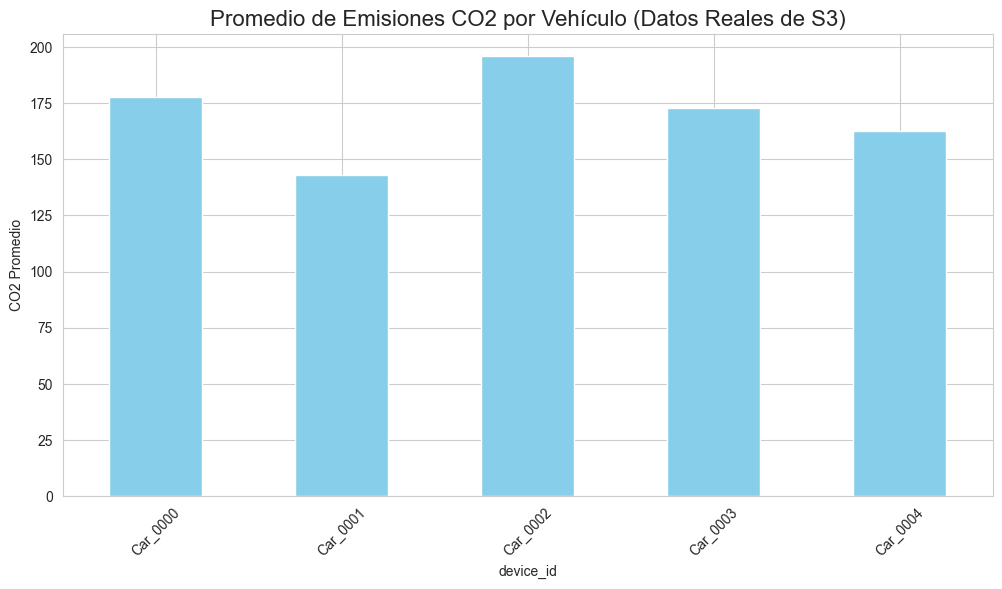

<Figure size 1200x600 with 0 Axes>

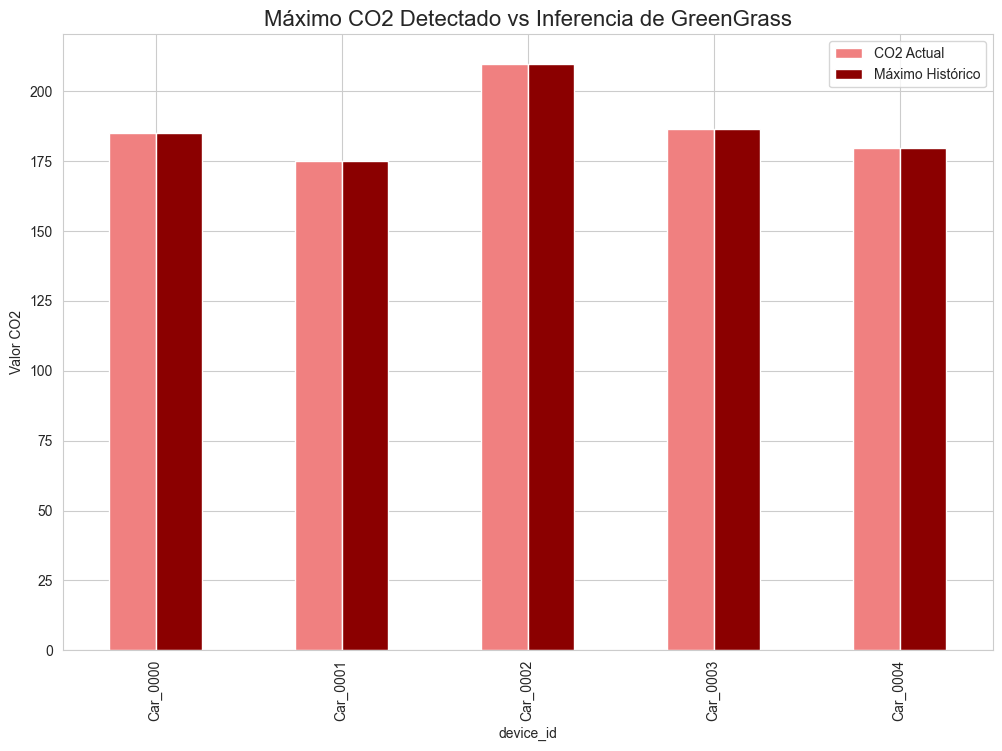

In [3]:
from pyathena import connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conexión a Athena usando tu bucket de resultados [cite: 435-436, 391]
conn = connect(s3_staging_dir='s3://lab4-athena-results-luis/',
               region_name='us-east-2')

# 2. Consulta SQL con tus nombres reales de Glue
# Nota: Si los campos están anidados, usa data.vehicle_CO2. Si no, usa el nombre directo.
query = """
SELECT 
    device_id, 
    vehicle_co2, 
    max_co2 
FROM "car_emissions_db"."emissions_data"
"""

# 3. Cargar datos desde la nube [cite: 440]
df = pd.read_sql(query, conn)

# --- Visualizaciones de Alta Calidad [cite: 525] ---
sns.set_style("whitegrid")

# Visualización 1: Promedio de CO2 por Vehículo
plt.figure(figsize=(12, 6))
df.groupby('device_id')['vehicle_co2'].mean().plot(kind='bar', color='skyblue')
plt.title('Promedio de Emisiones CO2 por Vehículo (Datos Reales de S3)', fontsize=16)
plt.ylabel('CO2 Promedio')
plt.xticks(rotation=45)
plt.show()

# Visualización 2: Comparativa de Emisiones (Actual vs Máximo)
plt.figure(figsize=(12, 6))
df_pivot = df.groupby('device_id')[['vehicle_co2', 'max_co2']].max()
df_pivot.plot(kind='bar', color=['lightcoral', 'darkred'])
plt.title('Máximo CO2 Detectado vs Inferencia de GreenGrass', fontsize=16)
plt.ylabel('Valor CO2')
plt.legend(['CO2 Actual', 'Máximo Histórico'])
plt.show()